In [2]:
#%%
import sys
import os

# # Add your project src to the path if needed
sys.path.append("/Users/evillz/Github/GUI_dev_YS_LV/src/pyfmreader-dynamo/src")

# from pyfmreader.jpk.loadjpkimg import loadJPKimg
from pyfmreader.ps_nex.loadpsneximg import loadPSNEXimg, createPSNEXimgcsv
from pyfmreader.ps_nex.loadpsnexMaps import checkMapFileNULL
# from pyfmreader.ps_nex
from pyfmreader import loadfile
from pyfmreader.ps_nex.parseTDMS import grab_tdms
import matplotlib.pyplot as plt


In [3]:

# Path to your test JPK file
# JPK_PATH = "/Users/evillz/Github/GUI_dev_YS_LV/src/pyfmreader-dynamo/tests/testfiles/map-data-2021.11.05-17.37.44.432.jpk-force-map"  # <-- Change this to your file
psnex_map_path = "/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71"
psnex_map_file = "/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/fcurve___2025.05.30_17.46.09.31.tdms"

# psnex_map_path = '/Users/evillz/Data/psnex_map___2025.03.12_18.23.11.20'
# psnex_map_file = '/Users/evillz/Data/psnex_map___2025.03.12_18.23.11.20/fcurve___2025.03.12_18.23.14.50.tdms'

# psnex_map_path = '/Users/evillz/Data/article/2025_23_05/psnex_map___2025.05.23_18.13.36.54'
# psnex_map_file = '/Users/evillz/Data/article/2025_23_05/psnex_map___2025.05.23_18.13.36.54/fcurve___2025.05.23_18.28.05.65.tdms'


# psnex_map_path = '/Users/evillz/Data/article/2025_23_05/psnex_map___2025.05.23_18.13.36.54'
# psnex_map_file = '/Users/evillz/Data/article/2025_23_05/psnex_map___2025.05.23_18.13.36.54/fcurve___2025.05.23_18.28.05.65.tdms'

# psnex_map_path = '/Volumes/SSK Drive /2025_30_5/psnex_map___2025.05.30_17.44.50.71'
# psnex_map_path = '/Volumes/SSK Drive /2025_11_06/psnex_map___2025.06.11_17.02.03.21'


In [4]:

scanFolder = True

if scanFolder :
    try: 
        checkMapFileNULL(psnex_map_path)
    except:
        pass

# Load the file using your project's loader
first_file, _ = grab_tdms(psnex_map_path)

print (f'Analyzing TDMS file : {first_file}')

UFF = loadfile(first_file)


#%%
# Debug: print some metadata
# print("File metadata:", UFF.filemetadata)

# system_{ax}_piezo_sensitivity_(nm/V)

x_piezo_sensitivity_nmV = UFF.filemetadata.get('system_X_piezo_sensitivity_(nm/V)')
y_piezo_sensitivity_nmV = UFF.filemetadata.get('system_Y_piezo_sensitivity_(nm/V)')

# Needs to be finilized
UFF.filemetadata['isFV'] = True
UFF.filemetadata['num_x_pixels'] = 32
UFF.filemetadata['num_y_pixels'] = 32
# UFF.filemetadata['scan_size_x_um'] = x_piezo_sensitivity_nmV * 1e-03 * (UFF.filemetadata['num_x_pixels']-1)
# UFF.filemetadata['scan_size_y_um'] = y_piezo_sensitivity_nmV * UFF.filemetadata['num_y_pixels']
UFF.filemetadata['scan_size_x_um'] = 0
UFF.filemetadata['scan_size_y_um'] = 0
# #%%
# #%%
# # Call the function and print results
piezoImage, data = loadPSNEXimg(UFF)
# csv_file_path, data = createPSNEXimgcsv(UFF)
print (piezoImage.shape)
# data

print("Loaded channels:", list(data.keys()))
for channel, img in data.items():
    print(f"Channel: {channel}, shape: {img.shape}, dtype: {img.dtype}")
print("Piezo image shape:", piezoImage.shape)


processing file : /Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71
0 9651
App
overshoot in the approach, accounted for   
success
5271 25825
Ret
segment duration 0.19302945, 
 numb of point cal (ticks, dec, sampling rate 9651, num pts stored per segment 96514
segment duration 0.32348475, 
 numb of point cal (ticks, dec, sampling rate 16174, num pts stored per segment 161741
df_point log made
0 30889
App
overshoot in the approach, accounted for   
success
30981 47061
Ret
segment duration 0.617792, 
 numb of point cal (ticks, dec, sampling rate 30889, num pts stored per segment 308895
segment duration 0.323449, 
 numb of point cal (ticks, dec, sampling rate 16172, num pts stored per segment 161723
df_point log made
0 30134
App
overshoot in the approach, accounted for   
success
30200 46306
Ret
segment duration 0.602685, 
 numb of point cal (ticks, dec, sampling rate 30134, num pts stored per segment 301342
segment duration 0.32345075, 
 numb of point cal (ticks, de

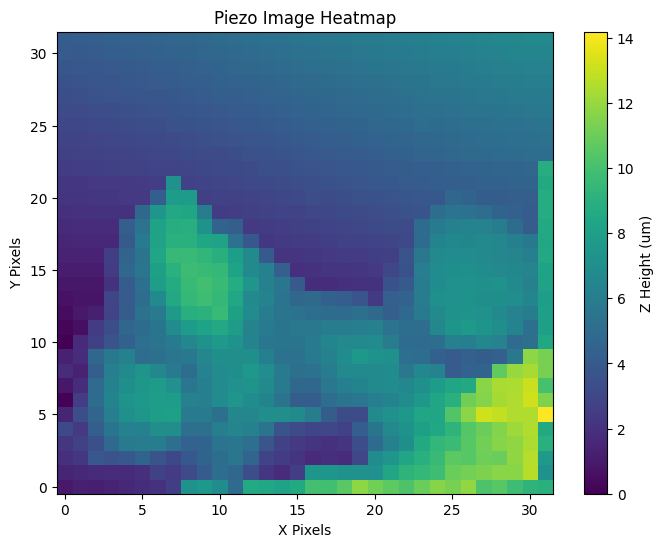

In [5]:
plt.figure(figsize=(8, 6))
plt.imshow(piezoImage, cmap='viridis', aspect='auto', origin='lower')
plt.colorbar(label='Z Height (um)')
plt.title('Piezo Image Heatmap')
plt.xlabel('X Pixels')
plt.ylabel('Y Pixels')
plt.show(block=True)